# 🎬 Analyse des facteurs de succès des films

## Objectif du projet

L'objectif de cette analyse est d'identifier les variables qui ont un impact sur le succès d'un film au box-office.

Dataset utilisé : `movies.csv`(voir github)

Variables principales :
- budget
- gross (revenus)
- score
- votes
- genre
- year

## Questions d'analyse

1. Y a t-il corrélation entre le **budget** et les **revenus** ?
2. Les films bien notés rapportent‑ils plus d'argent ?
3. La popularité (votes) influence‑t‑elle les revenus ?
4. Quels sont les films ayant généré le plus de revenus ?

## Technologies utilisées

- Python
- Pandas
- Numpy
- Seaborn
- Matplotlib


## Importation des librairies

In [5]:
# Import des librairies nécessaires pour l'analyse

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")


## Chargement du dataset

In [6]:
# Chargement du dataset

df = pd.read_csv("movies/movies.csv")

# Aperçu des données
df.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Exploration initiale des données

In [7]:
# Dimensions du dataset
df.shape


(7668, 15)

In [8]:
# Types des variables
df.dtypes


name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [9]:
# Vérification des valeurs manquantes

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print(f"{col} : {pct_missing:.2%} de valeurs manquantes")


name : 0.00% de valeurs manquantes
rating : 1.00% de valeurs manquantes
genre : 0.00% de valeurs manquantes
year : 0.00% de valeurs manquantes
released : 0.03% de valeurs manquantes
score : 0.04% de valeurs manquantes
votes : 0.04% de valeurs manquantes
director : 0.00% de valeurs manquantes
writer : 0.04% de valeurs manquantes
star : 0.01% de valeurs manquantes
country : 0.04% de valeurs manquantes
budget : 28.31% de valeurs manquantes
gross : 2.46% de valeurs manquantes
company : 0.22% de valeurs manquantes
runtime : 0.05% de valeurs manquantes


## Nettoyage des données

In [10]:
# Suppression des doublons éventuels

df = df.drop_duplicates()
df.shape


(7668, 15)

## Analyse : Budget vs Revenus

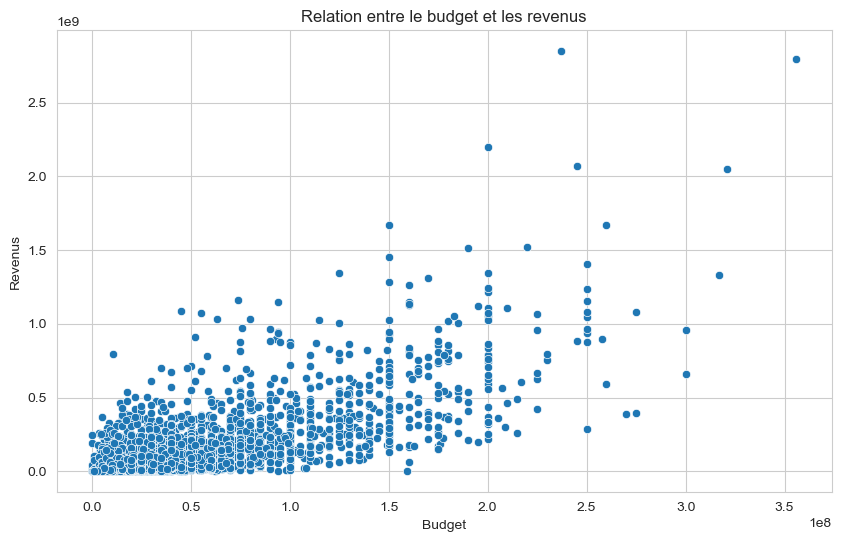

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="budget", y="gross", data=df)

plt.title("Relation entre le budget et les revenus")
plt.xlabel("Budget")
plt.ylabel("Revenus")

plt.show()


## Matrice de corrélation

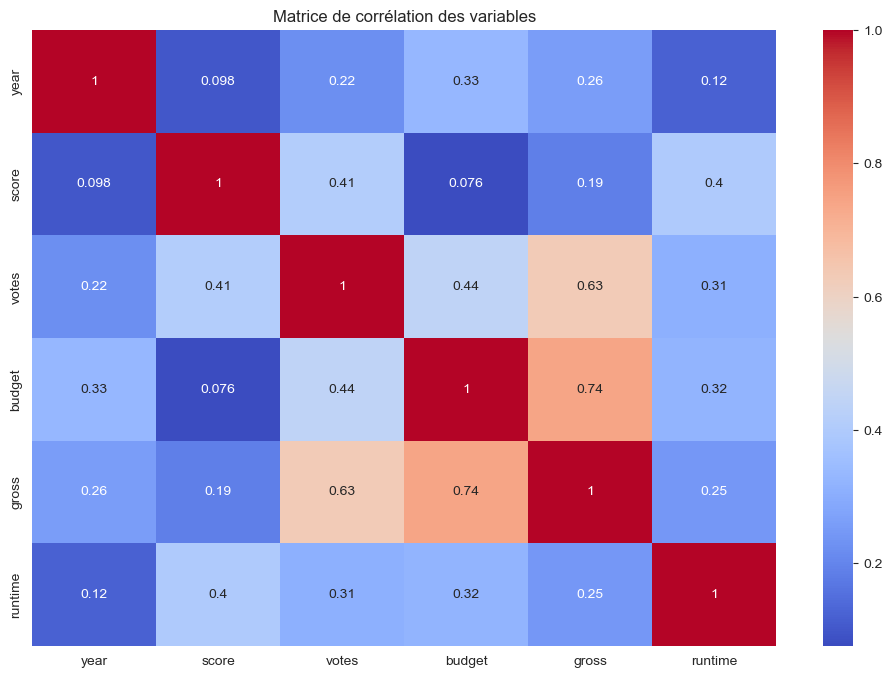

In [13]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matrice de corrélation des variables")

plt.show()


## Top 10 des films avec le plus de revenus

In [14]:
top_movies = df.sort_values(by="gross", ascending=False).head(10)

top_movies[["name","year","gross"]]


,name,year,gross
5445,Avatar,2009,2.847246e+09
7445,Avengers: Endgame,2019,2.797501e+09
3045,Titanic,1997,2.201647e+09
6663,Star Wars: Episode VII - The Force Awakens,2015,2.069522e+09
7244,Avengers: Infinity War,2018,2.048360e+09
7480,The Lion King,2019,1.670728e+09
6653,Jurassic World,2015,1.670516e+09
6043,The Avengers,2012,1.518816e+09
6646,Furious 7,2015,1.515341e+09
7494,Frozen II,2019,1.450027e+09


## Distribution des scores

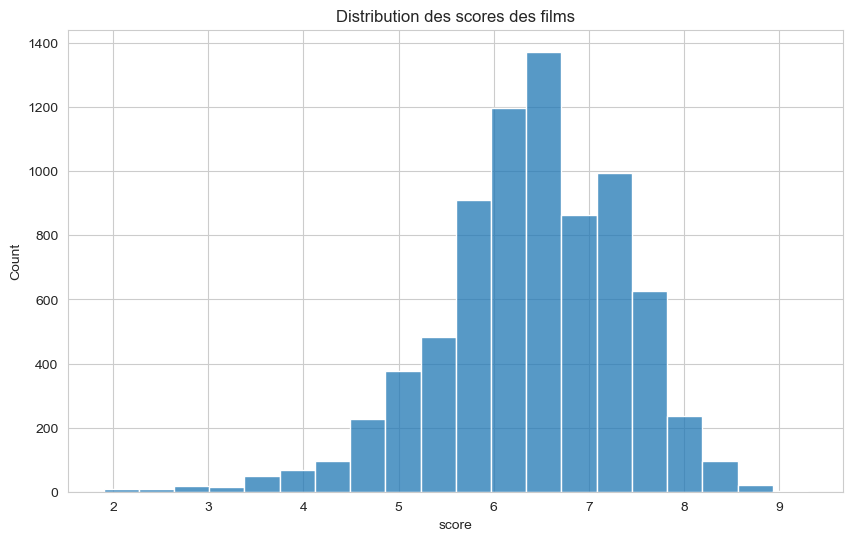

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(df["score"], bins=20)

plt.title("Distribution des scores des films")

plt.show()


## Conclusions

Principaux résultats :

- Le **budget** est fortement corrélé aux revenus des films.
- Les films ayant beaucoup de **votes** ont tendance à générer plus de revenus.
- Le **score critique** influence moins directement le succès commercial.

Ce projet démontre des compétences en :
- nettoyage de données
- analyse exploratoire (EDA)
- visualisation de données
- interprétation des résultats
